<a href="https://colab.research.google.com/github/flipz357/XPLAINSIM/blob/main/xplain/use_case_notebooks/walk_through_examples_xplainsim_DEMO_VIDEO_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# XPLAINSIM: Walkthrough Tutorial

This notebook accompanies the XPLAINSIM package and demonstrates three major approaches for explaining semantic text similarity. It is structured into three main parts:

0. [Short Pitch plots](#ShortPitch)

1. [Installation](#Installation)

2. [Getting Started: Similarity Attributions](#Attributions)

3. [Advanced: Shaping Embedding Spaces](#Spaceshaping)

4. [Symbolic Explanation via Meaning Representations](#Symbolic-similarity)

<a name="ShortPitch"></a>
# Plots for the Short Pitch

## Attributions

### Monolingual attributions

Before or after running the next cell, **feel ree to re-run to gain neural similarity explanations for any text of your choice.**

Note that the shown attribution matrix sums up to exactly the similarity that is provided by the model, this makes this explanation very faithful to any off-the-shelf transformer model.

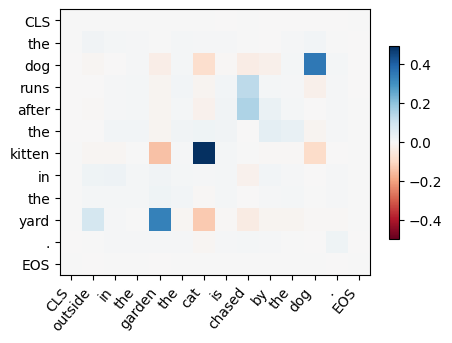

### Crosslingual attributions

Let's dive into **multi-lingual embedding models**. We load a multi-lingual model and compare similarity explanations from attributions when matching texts from different languages.

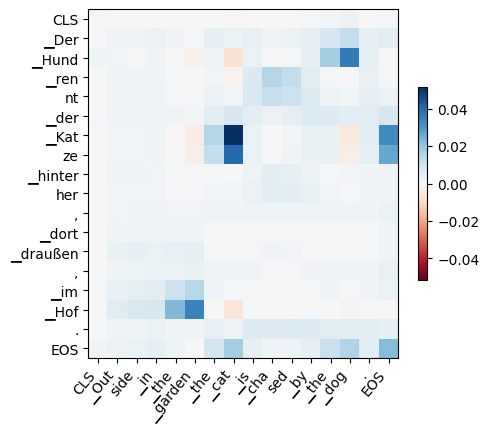



### Let's Align: Executing our Post-Processing Method


Our package contributes methods for retrieving a discrete alignment from attrbution matrices.

For better understanding, we also summarize the sub-words to words.

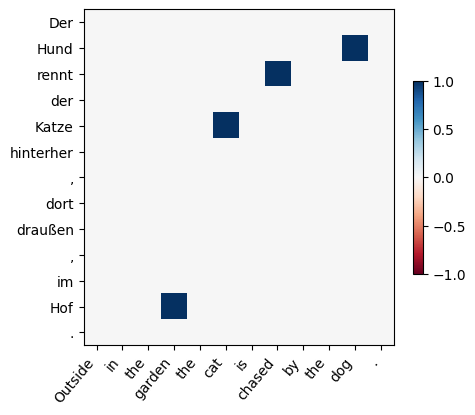

## Space Shaping

We toy train a space shaped model that distinguishes between lexical and entity wise similarities.

Let's plot the explanation of similarity for our two sample sentences
1. "The kitten drinks milk"
2. "A cat slurps something"

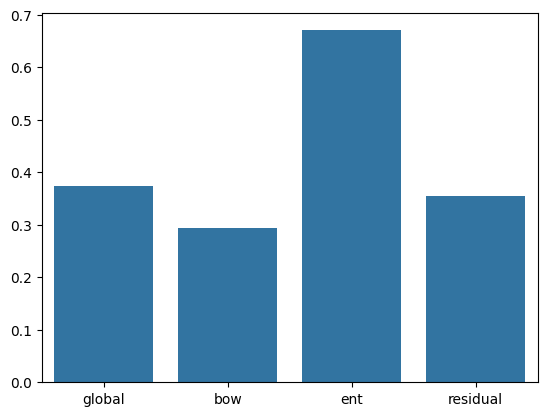

This is a sample plot that showcases that these text match in meaning of the entities but not so much on exact lexical match (bow)

# Symbolic Similarity via AMR

We run symbolic similarity using an AMR parser for the following two sample sentences

1.   Barack Obama holds a talk
2.   Hillary Clinton holds a talk

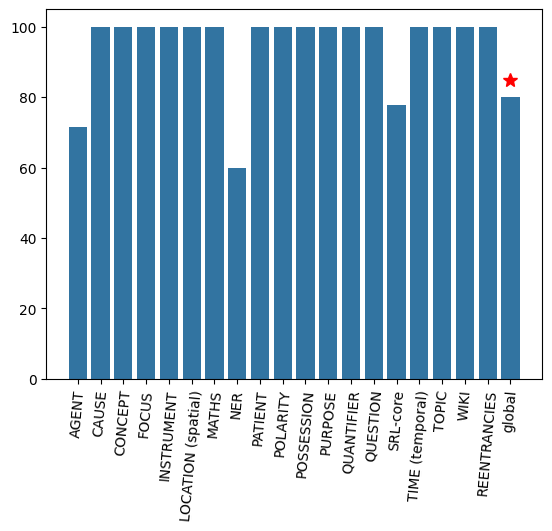

This showcases that the two texts are identical but only differ in exactly one Named Entity - Barack Obama / Hilary Clinton


<a name="Installation"></a>
# Installation

We begin by installing the XPLAINSIM package. This may take a few minutes. You might encounter a warning related to the datasets library—this can be safely ignored.

In [1]:
!pip install xplainsim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 1.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.6/230.6 kB 9.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.7/345.7 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 97.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.2/88.2 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 86.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.2/181.2 MB 6.3 MB/s eta 0:00:00
  Created wheel for xplain

## Install Seaborn for Visualisation

In [2]:
%pip install seaborn
import os
os.environ["WANDB_SILENT"] = "true"
os.environ["WANDB_DISABLED"] = "true"

<a name="Attributions"></a>
#Attributions

<a name="Exploring Similarity with Token Attributions"></a>
## For starters: Explore Semantic Similarity With Attributions

Text embeddings from models like SBERT are widely used in NLP, yet they typically offer no insight into why two texts are considered similar. The attribution module in XPLAINSIM enables us to inspect token-level contributions to similarity scores.

In [3]:
# First we import from our XPLAINSIM package
from xplain.attribution import ModelFactory
from xplain.attribution import plot_attributions

For using alignment to post-process attributions, please install pyemd


Let’s inspect supported models:

In [4]:
from pprint import pprint
models = ModelFactory.show_options()
print("All available models:")
pprint(models)

All available models:
['all-mpnet-base-v2',
 'xlm-roberta-base',
 'multilingual-e5-base',
 'paraphrase-multilingual-mpnet-base',
 'paraphrase-multilingual-MiniLM',
 'gte-multilingual-base',
 'sentence-transformers/all-mpnet-base-v2',
 'FacebookAI/xlm-roberta-base',
 'intfloat/multilingual-e5-base',
 'sentence-transformers/paraphrase-multilingual-mpnet-base-v2',
 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2',
 'Alibaba-NLP/gte-multilingual-base']


### Monolingual attributions

Before or after running the next cell, **feel ree to re-run to gain neural similarity explanations for any text of your choice.**

Note that the shown attribution matrix sums up to exactly the similarity that is provided by the model, this makes this explanation very faithful to any off-the-shelf transformer model.

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

100%|██████████| 768/768 [05:29<00:00,  2.33it/s]


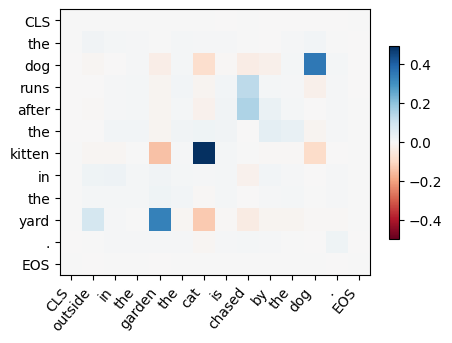

In [5]:
# Let's define two texts.
texta = "The dog runs after the kitten in the yard."
textb = "Outside in the garden the cat is chased by the dog."

# We select a popular "SBERT" model
model = ModelFactory.build("all-mpnet-base-v2")

# We generate the attributions
A, tokens_a, tokens_b = model.explain_similarity(texta, textb)

# For visualization, we plot this explanation
f = plot_attributions(
        A,
        tokens_a,
        tokens_b,
        size=(5, 5),
        # range=.3,
        show_colorbar=True,
        shrink_colorbar=0.5,
    )

#





























## Cross-Lingual Attributions

Let's dive into **multi-lingual embedding models**. We load a multi-lingual model and compare similarity explanations from attributions when matching texts from different languages.

(Again, before or after running the next cell, feel ree to re-run to gain neural similarity explanations for any text of your choice.)


config.json:   0%|          | 0.00/723 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/402 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

No hook has been registered.


100%|██████████| 768/768 [05:10<00:00,  2.47it/s]


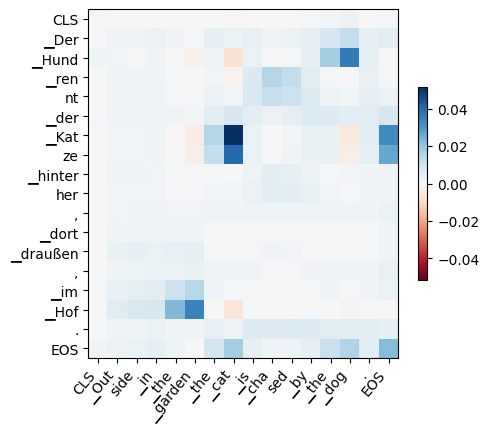

In [6]:

# Let's define two roughly parallel texts, the first one is German.
texta = "Der Hund rennt der Katze hinterher, dort draußen, im Hof."
textb = "Outside in the garden the cat is chased by the dog."

# We select a popular Multi-Lingual SOTA model
model = ModelFactory.build("sentence-transformers/paraphrase-multilingual-mpnet-base-v2")

# We generate the attributions
A, tokens_a, tokens_b = model.explain_similarity(texta, textb)

# For visualization, we plot this explanation
f = plot_attributions(
        A,
        tokens_a,
        tokens_b,
        size=(5, 5),
        # range=.3,
        show_colorbar=True,
        shrink_colorbar=0.5,
    )

### Let's Align: Executing our Post-Processing Method

Our package contributes methods for retrieving a discrete alignment from attrbution matrices.

For better understanding, we also summarize the sub-words to words.

We use the MaxAlign method from our paper. To use the slightly stronger FlowAlign method, please install `pyemd`.

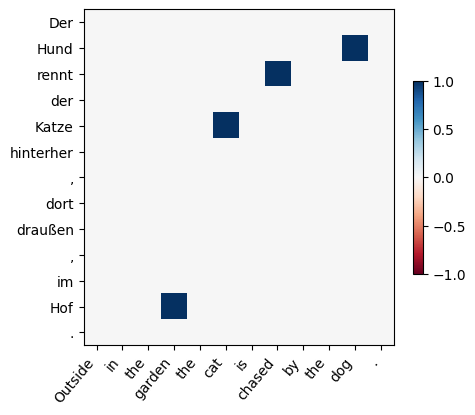

In [7]:
A_pp, tokens_a_pp, tokens_b_pp = model.postprocess_attributions(A, tokens_a, tokens_b, subtokens_aggregation_method="sum", sparsification_method="MaxAlign")

f = plot_attributions(
        A_pp,
        tokens_a_pp,
        tokens_b_pp,
        size=(5, 5),
        # range=.3,
        show_colorbar=True,
        shrink_colorbar=0.5,
    )

# Space Shaping

<a name="Spaceshaping"></a>

The space shaping module enables users to customize semantic similarity by training models that explicitly learn interpretable similarity aspects (e.g., entity overlap, word overlap).

<a name="Advanced-Shape-your-Own-Spaces"></a>
## Advanced: Shape your Own Spaces




Let's run a few further imports.

In [8]:
!pip install spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 63.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [9]:
from scipy.stats import pearsonr
from xplain.spaceshaping import PartitionedSentenceTransformer
from sentence_transformers import InputExample
from datasets import load_dataset
import spacy
nlp = spacy.load("en_core_web_sm")

Prepare Toy Data

In [10]:
# let's first load a toy train dataset of sentence pairs
ds = load_dataset("mteb/stsbenchmark-sts")
some_pairs = list(zip([dic["sentence1"] for dic in ds["train"]], [dic["sentence2"] for dic in ds["train"]]))

# dev dataset of sentence pairs
some_pairs_dev = list(zip([dic["sentence1"] for dic in ds["validation"]], [dic["sentence2"] for dic in ds["validation"]]))

README.md: 0.00B [00:00, ?B/s]

train.jsonl.gz:   0%|          | 0.00/278k [00:00<?, ?B/s]

validation.jsonl.gz:   0%|          | 0.00/86.4k [00:00<?, ?B/s]

test.jsonl.gz:   0%|          | 0.00/63.2k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5749 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1500 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1379 [00:00<?, ? examples/s]

Define Custom Similarity Metrics

The model will learn to reflect these in the neural embedding space, using them to construct the overall similarity.

In [11]:
def bow_sim(x1, x2):
        x1 = set(x1.split())
        x2 = set(x2.split())
        inter = x1.intersection(x2)
        union = x1.union(x2)
        return len(inter) / len(union)

def ent_sim(doc1, doc2):
        x1_ner = " ".join([ne.text for ne in doc1.ents])
        x2_ner = " ".join([ne.text for ne in doc2.ents])
        if not x1_ner and not x2_ner:
                return 1.0
        return bow_sim(x1_ner, x2_ner)

Prepare Training Examples

In [12]:
docs1, docs2 = [nlp(x) for x, _ in some_pairs], [nlp(y) for _, y in some_pairs]
target = [[bow_sim(x1, x2), ent_sim(docs1[i], docs2[i])] for i, (x1, x2) in enumerate(some_pairs)]
some_examples = [InputExample(texts=[x1, x2], label=target[i]) for (i, (x1, x2)) in enumerate(some_pairs)]

docs1_dev, docs2_dev = [nlp(x) for x, _ in some_pairs_dev], [nlp(y) for _, y in some_pairs_dev]
target_dev = [[bow_sim(x1, x2), ent_sim(docs1_dev[i], docs2_dev[i])] for i, (x1, x2) in enumerate(some_pairs_dev)]
some_examples_dev = [InputExample(texts=[x1, x2], label=target_dev[i]) for (i, (x1, x2)) in enumerate(some_pairs_dev)]

Train and Evaluate

In [13]:
# init model
pt = PartitionedSentenceTransformer(feature_names=["bow", "ent"], feature_dims=[32, 32])
json = pt.explain_similarity([x for x, y in some_pairs_dev], [y for x, y in some_pairs_dev])

# eval correlation to custom metric before training
print("Initial correlation of model with bag of words distance: {}".format(pearsonr([x.label[0] for x in some_examples_dev], [dic["bow"] for dic in json])))
print("Initial correlation of model with Entity distance: {}".format(pearsonr([x.label[1] for x in some_examples_dev], [dic["ent"] for dic in json])))

# print a toy example before training
print("Explaining a toy pair", pt.explain_similarity(["The kitten drinks milk"], ["A cat slurps something"]))

# train
pt.train_model(some_examples, some_examples_dev)

# eval correlation to custom metric after train
json = pt.explain_similarity([x for x, y in some_pairs_dev], [y for x, y in some_pairs_dev])
print("New correlation of model with bag of words distance: {}".format(pearsonr([x.label[0] for x in some_examples_dev], [dic["bow"] for dic in json])))
print("New correlation of model with Entity distance: {}".format(pearsonr([x.label[1] for x in some_examples_dev], [dic["ent"] for dic in json])))

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

...

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss,Validation Loss,Evaluator
180,No log,No log,-0.134966


New correlation of model with bag of words distance: PearsonRResult(statistic=np.float64(0.6188125778525012), pvalue=np.float64(3.0415935681120097e-159))
New correlation of model with Entity distance: PearsonRResult(statistic=np.float64(0.6144235318076753), pvalue=np.float64(2.1234393531376856e-156))


In [14]:
# print a toy example after training
print("Explaining a toy pair", pt.explain_similarity(["The kitten drinks milk"], ["A cat slurps something"]))

Explaining a toy pair [{'sent_a': 'The kitten drinks milk', 'sent_b': 'A cat slurps something', 'bow': 0.467467337846756, 'ent': 0.8029885292053223, 'residual': 0.44781434535980225, 'global': 0.484554260969162}]


Let's plot the explanation of similarity for our two sentences "The kitten drinks milk" and "A cat slurps something".

/tmp/ipykernel_12503/2573174749.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0)


[Text(0, 0, 'bow'),
 Text(1, 0, 'ent'),
 Text(2, 0, 'residual'),
 Text(3, 0, 'global')]

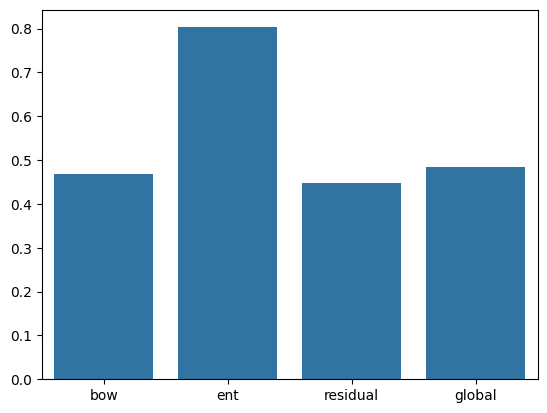

In [15]:
import seaborn as sns
ax = sns.barplot({key:value for key, value in pt.explain_similarity(["The kitten drinks milk"], ["A cat slurps something"])[0].items() if not key in ["sent_a", "sent_b"]})
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

This is it, you learnt to shape your own spaces! Improvements and some ideas for testing:

- Implement your custom similarity aspects

- Decide on different Feature Sizes

- Train on Larger Data

<a name="Symbolic-similarity"></a>
# Symbolic Similarity via AMR

The symbolic module uses AMR (Abstract Meaning Representation) to compare texts based on their semantic structure.

Let's install the AMR lib library first, and smatchpp first. The first is used as default parser, and the second as default similarity metric.

In [16]:
%pip install amrlib
%pip install unidecode
%pip install smatchpp

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 353.3/353.3 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.4/43.4 kB 2.6 MB/s eta 0:00:00
  Created wheel for smatch: filename=smatch-1.0.4-py3-none-any.whl size=24134 sha256=dc103489b6b4cd8cee63af06fe6a91a9792962e8941ce4187c8761f27297d6b6
  Stored in directory: /root/.cache/pip/wheels/33/d8/1e/c9ce3b7a4c71d5fcaadd8026e13bf1774045b4069dcb1cacd5
Successfully built smatch


Example Usage

In [17]:
!xplain-install-amr

model_parse_xfm_bart_base-v0_1_0/
model_parse_xfm_bart_base-v0_1_0/model_parse_xfm_bart_base.json
model_parse_xfm_bart_base-v0_1_0/config.json
model_parse_xfm_bart_base-v0_1_0/pytorch_model.bin
model_parse_xfm_bart_base-v0_1_0/amrlib_meta.json


In [18]:
from xplain.symbolic.model import AMRSimilarity

explainer = AMRSimilarity()
sents1 = ["Barack Obama holds a talk"]
sents2 = ["Hillary Clinton holds a talk"]
exp = explainer.explain_similarity(sents1, sents2, return_graphs=True)
print(exp)

config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

[{'sent_a': 'Barack Obama holds a talk', 'sent_b': 'Hillary Clinton holds a talk', 'AGENT': {'f1': np.float64(0.7142857142857143), 'precision': np.float64(0.7142857142857143), 'recall': np.float64(0.7142857142857143), 'subgraph1': [('h', ':arg0', 'p'), ('n', ':op1', 'barack'), ('p', ':name', 'n'), ('h', ':instance', 'hold-04'), ('n', ':instance', 'name'), ('n', ':op2', 'obama'), ('p', ':instance', 'person')], 'subgraph2': [('h', ':arg0', 'p'), ('n', ':op1', 'hillary'), ('n', ':op2', 'clinton'), ('p', ':name', 'n'), ('h', ':instance', 'hold-04'), ('n', ':instance', 'name'), ('p', ':instance', 'person')], 'alignment': [('aa_h_hold-04', 'bb_h_hold-04'), ('aa_n_name', 'bb_n_name'), ('aa_p_person', 'bb_p_person')]}, 'CAUSE': {'f1': np.float64(1.0), 'precision': np.float64(1.0), 'recall': np.float64(1.0), 'subgraph1': [], 'subgraph2': [], 'alignment': []}, 'CONCEPT': {'f1': np.float64(1.0), 'precision': np.float64(1.0), 'recall': np.float64(1.0), 'subgraph1': [('h', ':instance', 'hold-04'), 

Plot the Result

We see that the lowest aspectual similarity is in the category "Named Entities".

/tmp/ipykernel_12503/1622265593.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=85)


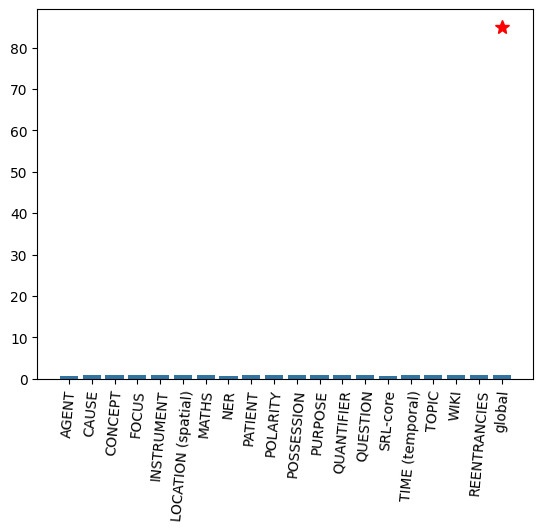

In [19]:
import seaborn as sns
ax = sns.barplot({key:exp[0][key]['f1'] for key in exp[0] if key not in ['sent_a', 'sent_b']})
ax.set_xticklabels(ax.get_xticklabels(), rotation=85)
ax.plot("global", 85, "*", markersize=10, color="r")

# Summary

Using XPLAINSIM, you can:

*   Explain similarity predictions of off-the-shelf embedding models (monolingual and multilingual)
*   Train embedding models to reflect custom similarity aspects (space shaping)
*   Obtain structured symbolic explanations via AMR

